## End-to-end tutorial: REINVENT → Maize → GOLD → scores back to REINVENT

This notebook demonstrates the **closed loop** that many practical design workflows need:

1. **REINVENT4** generates a batch of candidate molecules as **SMILES**.
2. **Maize** routes that batch through a graph of nodes.
3. **SMILES → molecules** conversion (so docking tools can consume 3D-ready structures).
4. **GOLD docking** evaluates each molecule against a prepared receptor and binding site.
5. **Score conversion** normalizes docking scores into the numeric range REINVENT expects.
6. The converted scores are **fed back** into REINVENT so the next epoch proposes better molecules.

### What Maize is doing here

Maize acts as the **orchestrator**: each node runs as its own process and communicates via ports/channels. This makes it straightforward to plug a generative model, chemistry conversion, and docking into one repeatable workflow.

### Prerequisites

- Tutorials 1–4 completed.
- A valid **CCDC license**.
- A REINVENT **prior** in `priors/`.
- Prepared protein + reference ligand in `data/` (e.g. `protein_prepared.mol2` and `4lqm_ligand.mol2`). You can also use your own target.
- A `config.toml` in the repo root (copy `config.toml.example` → `config.toml` and fill in tool paths).

### Important


In [32]:
import workshop_setup
from pathlib import Path
import os


In [33]:
from maize.core.workflow import Workflow
from pathlib import Path
from maize.steps.mai.molecule import Smiles2Molecules
from maize.steps.mai.misc import ReInvent
from nodes import GOLDDocking, SaveIsomers, ScoreConverter

In [ ]:
### THE PATHS IN THIS NOTEBOOK ARE EXAMPLES. PLEASE CHANGE THEM TO YOUR OWN PATHS ###

flow = Workflow(name='reinvent_dock')
###Before running the workflow, make sure to update the paths in the config.toml file. Add the correct environment variables and paths to the executables.
flow.config.update(Path('/nfs/home/myuecel3/Frontiers_MedChem/config.toml'))

rnve = flow.add(ReInvent)
smi2mol = flow.add(Smiles2Molecules, loop=True)
gold = flow.add(GOLDDocking, loop=True)
converter = flow.add(ScoreConverter, loop=True)

# GOLD configuration
gold.ndocking.set(10)
gold.scoring_function.set('plp')
gold.output_base_dir.set(Path('/nfs/home/myuecel3/Frontiers_MedChem/data/output'))  # Change this to your local output directory
gold.protein_file.set(Path('/nfs/home/myuecel3/Frontiers_MedChem/data/8bxh_jak2_protein_prepared.cif')) # Change this to your local protein file. 
gold.ref_ligand.set(Path('/nfs/home/myuecel3/Frontiers_MedChem/data/8bxh_jak2_ligand.mol2')) # Change this to your local reference ligand file.
# You can also choose 'from_ligand'
gold.binding_site_mode.set('from_ligand')


# REINVENT configuration
# You can also use the toml file that we generated in the previous notebook, but make sure to update the paths in it. Or you can create a new one woth new pararmetrs.
rnve_conf = Path('/nfs/home/myuecel3/Frontiers_MedChem/configs/reinvent_rl_config.toml')
rnve.configuration.set(rnve_conf)
## First, you might want to set the max epoch to a smaller number for testing. Then you can increase it for the final run.
rnve.max_epoch.set(20)  
rnve.low.set(0.0) # This is lowest score for docking score.
rnve.high.set(5) # Since we are optimziing the docking score by molecular weight, we can set the high score to 5. Normally the docking scores of GOLD are higher values like 60, 70 ...
rnve.reverse.set(False)
rnve.batch_size.set(32) 

# Connect the nodes
flow.connect(rnve.out, smi2mol.inp)
flow.connect(smi2mol.out, gold.inp)
flow.connect(gold.out, converter.inp)
flow.connect(converter.out, rnve.inp) 

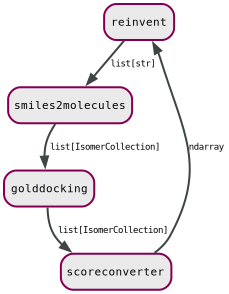

In [50]:
# Check and visualize the workflow
flow.check()
dot =flow.visualize()
dot.render('workflow_visualization', format='pdf') # This will save the visualization as a PDF file named 'workflow_visualization.pdf'
dot


In [51]:
# Execute the workflow
flow.execute()

2026-03-24 08:01:53,669 |     INFO |    reinvent_dock | 
              ___           ___                       ___           ___
             /\__\         /\  \          ___        /\  \         /\  \
            /::|  |       /::\  \        /\  \       \:\  \       /::\  \
           /:|:|  |      /:/\:\  \       \:\  \       \:\  \     /:/\:\  \
          /:/|:|__|__   /::\~\:\  \      /::\__\       \:\  \   /::\~\:\  \
         /:/ |::::\__\ /:/\:\ \:\__\  __/:/\/__/ _______\:\__\ /:/\:\ \:\__\
         \/__/~~/:/  / \/__\:\/:/  / /\/:/  /    \::::::::/__/ \:\~\:\ \/__/
               /:/  /       \::/  /  \::/__/      \:\~~\~~      \:\ \:\__\
              /:/  /        /:/  /    \:\__\       \:\  \        \:\ \/__/
             /:/  /        /:/  /      \/__/        \:\__\        \:\__\
             \/__/         \/__/                     \/__/         \/__/


2026-03-24 08:01:53,669 - INFO - 
              ___           ___                       ___           ___
             /\

2026-03-24 08:01:58,695 |     INFO |    reinvent_dock | Workflow status
                                   | smiles2molecules | WAITING_FOR_INPUT
                                   |   scoreconverter | WAITING_FOR_INPUT
                                   |      golddocking | WAITING_FOR_INPUT
                                   |         reinvent | WAITING_FOR_OUTPUT
2026-03-24 08:01:58,695 - INFO - Workflow status
                                   | smiles2molecules | WAITING_FOR_INPUT
                                   |   scoreconverter | WAITING_FOR_INPUT
                                   |      golddocking | WAITING_FOR_INPUT
                                   |         reinvent | WAITING_FOR_OUTPUT
2026-03-24 08:01:58,695 - INFO - Embedding 1/23 ('CSc1ccc(N2c3ccccc3N(CC(=O)N3CCNCC3)S2(=O)=O)cc1')
2026-03-24 08:01:58,695 |     INFO | smiles2molecules | Embedding 1/23 ('CSc1ccc(N2c3ccccc3N(CC(=O)N3CCNCC3)S2(=O)=O)cc1')
2026-03-24 08:01:58,695 - INFO - 2026-03-24 08:01:58,695 |    

2026-03-24 08:03:25,188 |     INFO |    reinvent_dock | Workflow status
                                   | smiles2molecules | WAITING_FOR_INPUT
                                   |   scoreconverter | WAITING_FOR_INPUT
                                   |      golddocking | RUNNING
                                   |         reinvent | WAITING_FOR_INPUT
2026-03-24 08:03:25,187 - INFO - Command output: Found 23 molecules in /nfs/home/myuecel3/Frontiers_MedChem/data/output/gold_docking_step1/ligands.sdf
Processing molecule 1/23
Unsetting the LD_LIBRARY_PATH environment variable.
Previous value was /nfs/home/myuecel3/miniforge3/envs/frontiers_medchem/lib:
Please do not rely on CCDC wrapper scripts doing this and ensure the directories in LD_LIBRARY_PATH do not interfere with CCDC provided libraries.
Setting up GOLD environment...
GOLD Version 2022.3.0
Running:
 
     "/appl/ccdc/CSDS2022/Discovery_2022/GOLD/gold/d_linux_64/bin/gold_linux_64" "/tmp/tmpxfbuh5c3/graph-reinvent_dock-z6jg0w/

2026-03-24 08:03:27,627 |     INFO |    reinvent_dock | Workflow status
                                   | smiles2molecules | WAITING_FOR_INPUT
                                   |   scoreconverter | WAITING_FOR_INPUT
                                   |      golddocking | WAITING_FOR_COMMAND
                                   |         reinvent | WAITING_FOR_INPUT
2026-03-24 08:03:27,627 - INFO - Workflow status
                                   | smiles2molecules | WAITING_FOR_INPUT
                                   |   scoreconverter | WAITING_FOR_INPUT
                                   |      golddocking | WAITING_FOR_COMMAND
                                   |         reinvent | WAITING_FOR_INPUT


2026-03-24 08:04:41,072 |     INFO |    reinvent_dock | Workflow status
                                   | smiles2molecules | WAITING_FOR_INPUT
                                   |   scoreconverter | WAITING_FOR_INPUT
                                   |      golddocking | RUNNING
                                   |         reinvent | WAITING_FOR_INPUT
2026-03-24 08:04:41,071 - INFO - Command output: Found 20 molecules in /nfs/home/myuecel3/Frontiers_MedChem/data/output/gold_docking_step2/ligands.sdf
Processing molecule 1/20
Unsetting the LD_LIBRARY_PATH environment variable.
Previous value was /nfs/home/myuecel3/miniforge3/envs/frontiers_medchem/lib:
Please do not rely on CCDC wrapper scripts doing this and ensure the directories in LD_LIBRARY_PATH do not interfere with CCDC provided libraries.
Setting up GOLD environment...
GOLD Version 2022.3.0
Running:
 
     "/appl/ccdc/CSDS2022/Discovery_2022/GOLD/gold/d_linux_64/bin/gold_linux_64" "/tmp/tmpxfbuh5c3/graph-reinvent_dock-z6jg0w/

2026-03-24 08:04:42,517 - INFO - Embedding 14/22 ('O=C(CN1CCC(c2ccccc2)CC1)NC(c1ccccc1)c1ccccc1')
2026-03-24 08:04:42,517 |     INFO | smiles2molecules | Embedding 14/22 ('O=C(CN1CCC(c2ccccc2)CC1)NC(c1ccccc1)c1ccccc1')
2026-03-24 08:04:42,517 - INFO - 2026-03-24 08:04:42,517 |     INFO | smiles2molecules | Embedding 14/22 ('O=C(CN1CCC(c2ccccc2)CC1)NC(c1ccccc1)c1ccccc1')
2026-03-24 08:04:42,537 - INFO - Embedding 15/22 ('O=C1CC(c2ccc(Cc3ccccc3O)cc2O)Oc2cc(O)ccc21')
2026-03-24 08:04:42,537 |     INFO | smiles2molecules | Embedding 15/22 ('O=C1CC(c2ccc(Cc3ccccc3O)cc2O)Oc2cc(O)ccc21')
2026-03-24 08:04:42,537 - INFO - 2026-03-24 08:04:42,537 |     INFO | smiles2molecules | Embedding 15/22 ('O=C1CC(c2ccc(Cc3ccccc3O)cc2O)Oc2cc(O)ccc21')
2026-03-24 08:04:42,555 - INFO - Embedding 16/22 ('c1ccc(-c2ccc(CCN3CCN(c4ncccn4)CC3)cc2)cc1')
2026-03-24 08:04:42,555 |     INFO | smiles2molecules | Embedding 16/22 ('c1ccc(-c2ccc(CCN3CCN(c4ncccn4)CC3)cc2)cc1')
2026-03-24 08:04:42,555 - INFO - 2026-03-24 08:

Process Logger:
2026-03-24 08:05:07,738 - INFO - Received interrupt
2026-03-24 08:05:07,738 - INFO - Received interrupt
2026-03-24 08:05:07,738 - INFO - Received interrupt
Process reinvent:
Process golddocking:
Process scoreconverter:
Traceback (most recent call last):
  File "/nfs/home/myuecel3/miniforge3/envs/frontiers_medchem/lib/python3.10/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
Traceback (most recent call last):
  File "/nfs/home/myuecel3/miniforge3/envs/frontiers_medchem/lib/python3.10/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
Traceback (most recent call last):
  File "/nfs/home/myuecel3/miniforge3/envs/frontiers_medchem/lib/python3.10/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/nfs/home/myuecel3/miniforge3/envs/frontiers_medchem/lib/python3.10/site-packages/maize/core/runtime.py", line 631, in execute
    message = self.queue.get()
  File "/nfs/home/myuecel3/miniforge3/

KeyboardInterrupt: 

**Note:**

If you trained long enough, you might see how the scores improved over time

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
# Load the results from the CSV file
results_df = pd.read_csv('/nfs/home/myuecel3/Frontiers_MedChem/data/output/reinvent_maize_gold_1.csv') ## Change this to the path of your output CSV file
results_df = results_df.groupby('step')['Score'].mean().reset_index() # Average score for each step
# Plot the docking scores over steps
plt.figure(figsize=(10, 6))
plt.plot(results_df['step'], results_df['Score'], marker='o')
plt.title('Average Scores over Steps')
plt.xlabel('Step')
plt.ylabel('Average Score')
plt.grid()
plt.show()